### Loading Libraries

In [1]:


import numpy as np
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile

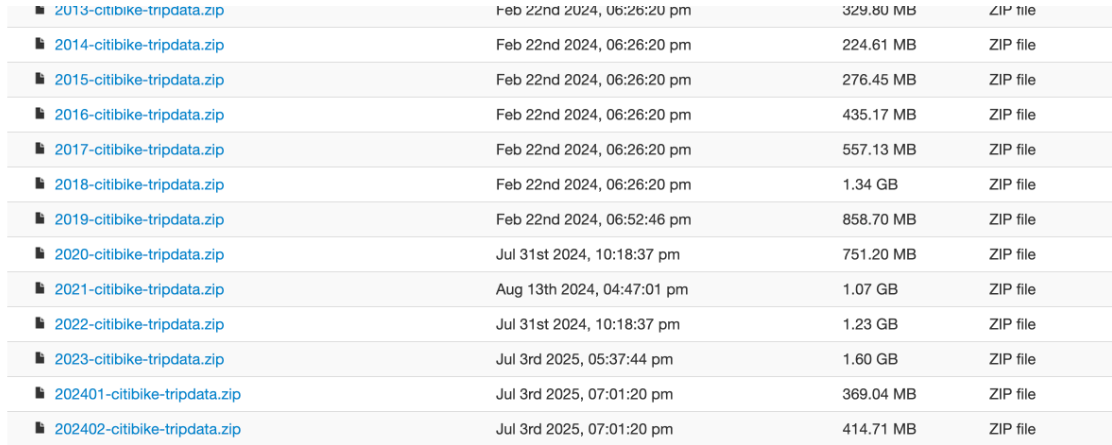

In [2]:
from IPython.display import Image, display

display(Image(filename='C:/Users/User/Pictures/Screenshots/Screenshot 2026-06-23 235703.png'))



In [4]:
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"
url = f"{CITIBIKE_INDEX_URL}/{file_name}"
url

'https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip'

### Download the CIti Bike Data for year 2025

In [3]:
def period_iterator(year:list,start_m:int, stop_m:int)->list:
    """
    
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    # print(periods)
    return periods

In [4]:
periods  = period_iterator(year = ['2025'],start_m = 1, stop_m = 12)

periods

['202502',
 '202503',
 '202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512']

In [5]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)


for i in periods:

    try:
        file_name = f"JC-{i}-citibike-tripdata.csv.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    except (HTTPError, URLError, FileNotFoundError):
        file_name = f"JC-{i}-citibike-tripdata.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)
    print(f'{file_name}  Extracted')
    zip_path.unlink()
    print(f"{file_name} removed.")


JC-202502-citibike-tripdata.csv.zip  Extracted
JC-202502-citibike-tripdata.csv.zip removed.
JC-202503-citibike-tripdata.csv.zip  Extracted
JC-202503-citibike-tripdata.csv.zip removed.
JC-202504-citibike-tripdata.csv.zip  Extracted
JC-202504-citibike-tripdata.csv.zip removed.
JC-202505-citibike-tripdata.csv.zip  Extracted
JC-202505-citibike-tripdata.csv.zip removed.
JC-202506-citibike-tripdata.csv.zip  Extracted
JC-202506-citibike-tripdata.csv.zip removed.
JC-202507-citibike-tripdata.csv.zip  Extracted
JC-202507-citibike-tripdata.csv.zip removed.
JC-202508-citibike-tripdata.csv.zip  Extracted
JC-202508-citibike-tripdata.csv.zip removed.
JC-202509-citibike-tripdata.csv.zip  Extracted
JC-202509-citibike-tripdata.csv.zip removed.
JC-202510-citibike-tripdata.zip  Extracted
JC-202510-citibike-tripdata.zip removed.
JC-202511-citibike-tripdata.csv.zip  Extracted
JC-202511-citibike-tripdata.csv.zip removed.
JC-202512-citibike-tripdata.csv.zip  Extracted
JC-202512-citibike-tripdata.csv.zip remov

####  Removing __MACOSX

In [6]:
import shutil

shutil.rmtree(output_dir / "__MACOSX")

###  Concatinating

In [7]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob(f'{output_dir}/*.csv')



dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(df.columns, 2*"||",len(df.columns))

    cols.append(list(df.columns))
    dfs.append(df)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual']

In [8]:
citibike_df = pd.concat(dfs)
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,04CF7A399050E404,classic_bike,2025-02-22 17:40:16.500,2025-02-22 17:47:22.479,Jersey & 3rd,JC074,Van Vorst Park,JC035,40.723332,-74.045953,40.718489,-74.047727,casual
1,124AC7493E82D845,classic_bike,2025-02-21 12:28:13.319,2025-02-21 12:35:44.762,Jersey & 3rd,JC074,Columbus Drive,JC014,40.723332,-74.045953,40.718355,-74.038914,member
2,1A3BCA838E968327,classic_bike,2025-02-01 14:17:43.272,2025-02-01 14:59:09.894,Jersey & 3rd,JC074,Grove St PATH,JC115,40.723332,-74.045953,40.719410,-74.043090,casual
3,5994017EE989D6EE,electric_bike,2025-02-22 11:36:29.292,2025-02-22 11:49:51.531,Jersey & 3rd,JC074,Jersey & 3rd,JC074,40.723332,-74.045953,40.723332,-74.045953,casual
4,F81BCB97915C6BE6,electric_bike,2025-02-28 22:56:26.546,2025-02-28 23:07:40.391,Jersey & 3rd,JC074,Monroe St & 11 St,HB508,40.723332,-74.045953,40.750109,-74.036637,casual


In [9]:
citibike_df.to_csv("../data/citibike/JC/JC2025.csv", index = False)


In [11]:
citibike_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952093 entries, 0 to 48473
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             952093 non-null  object 
 1   rideable_type       952093 non-null  object 
 2   started_at          952093 non-null  object 
 3   ended_at            952093 non-null  object 
 4   start_station_name  952090 non-null  object 
 5   start_station_id    952090 non-null  object 
 6   end_station_name    948965 non-null  object 
 7   end_station_id      947828 non-null  object 
 8   start_lat           952091 non-null  float64
 9   start_lng           952091 non-null  float64
 10  end_lat             948668 non-null  float64
 11  end_lng             948668 non-null  float64
 12  member_casual       952093 non-null  object 
dtypes: float64(4), object(9)
memory usage: 101.7+ MB


In [13]:
citibike_df.shape

(952093, 13)